# Improved Land-Use Classification with Transfer Learning

**Course:** Applied Data Science & Machine Intelligence: Fundamentals to Next
Generation AI 2026  
**Project:** Official Land Use Classification sample project  
**Submission target:** IIT Kanpur optional project certificate  
**Deadline:** 20 July 2026

This notebook improves the supplied five-class custom CNN using ImageNet transfer
learning. It compares ResNet18 and EfficientNet-B0 on the exact historical split and
on a separately reported group-aware split that keeps manually reviewed related scenes
together. The notebook is self-contained and requires no Kaggle or GitHub credential.


## Evaluation contract

- The direct comparison uses the same 5 classes, 500 images, and 350/75/75 historical
  manifest as the supplied notebook.
- Validation macro F1 selects checkpoints; each test partition is evaluated once only
  after model selection.
- The group-aware result is robustness evidence, not a replacement baseline.
- Accuracy, macro F1, balanced accuracy, top-3 accuracy, per-class scores, confusion
  matrices, training time, and parameter counts are exported.
- No result from an interrupted or failed experiment is treated as achieved.
- The supplied reference is 74.67% test accuracy and 0.733 macro F1.


## Verified Colab Pro GPU results — 13 July 2026

The returned results bundle was validated against its individual JSON files, comparison
CSV, confusion matrices, per-class supports, dataset checksum, and both manifest checksums.
It ran on an **NVIDIA L4** with no failed experiments.

| Model | Split | Parameters | Selected epoch | Test loss | Accuracy | Macro F1 |
|---|---|---:|---:|---:|---:|---:|
| Supplied custom CNN | Historical | 102,277 | 10 | Not reported | 74.67% | 0.733 |
| ResNet18 | Historical | 11,179,077 | 4 | 0.0247 | 100.00% | 1.000 |
| ResNet18 | Group-aware | 11,179,077 | 4 | 0.0294 | 100.00% | 1.000 |
| EfficientNet-B0 | Historical | 4,013,953 | 5 | 0.0457 | 100.00% | 1.000 |
| EfficientNet-B0 | Group-aware | 4,013,953 | 4 | 0.0804 | 100.00% | 1.000 |

**Selected final architecture: ResNet18.** Classification metrics tied, while ResNet18
produced lower loss on both manifests, completed the historical L4 run faster, and matched
the independently obtained local CPU evidence. EfficientNet-B0 is retained as the
parameter-efficient alternative.

Evidence bundle SHA-256:
`2c834a31ad37e07de11681f0e3596040d60f1c18e31142dfcdaa97b7a38837ae`
Evidence commit: `414233c8471ea961bfd9406a33f54b427e75ab49`

![Verified training curves and test confusion matrices][verified-figure]

[verified-figure]: attachment:training_and_confusion_colab_l4.png

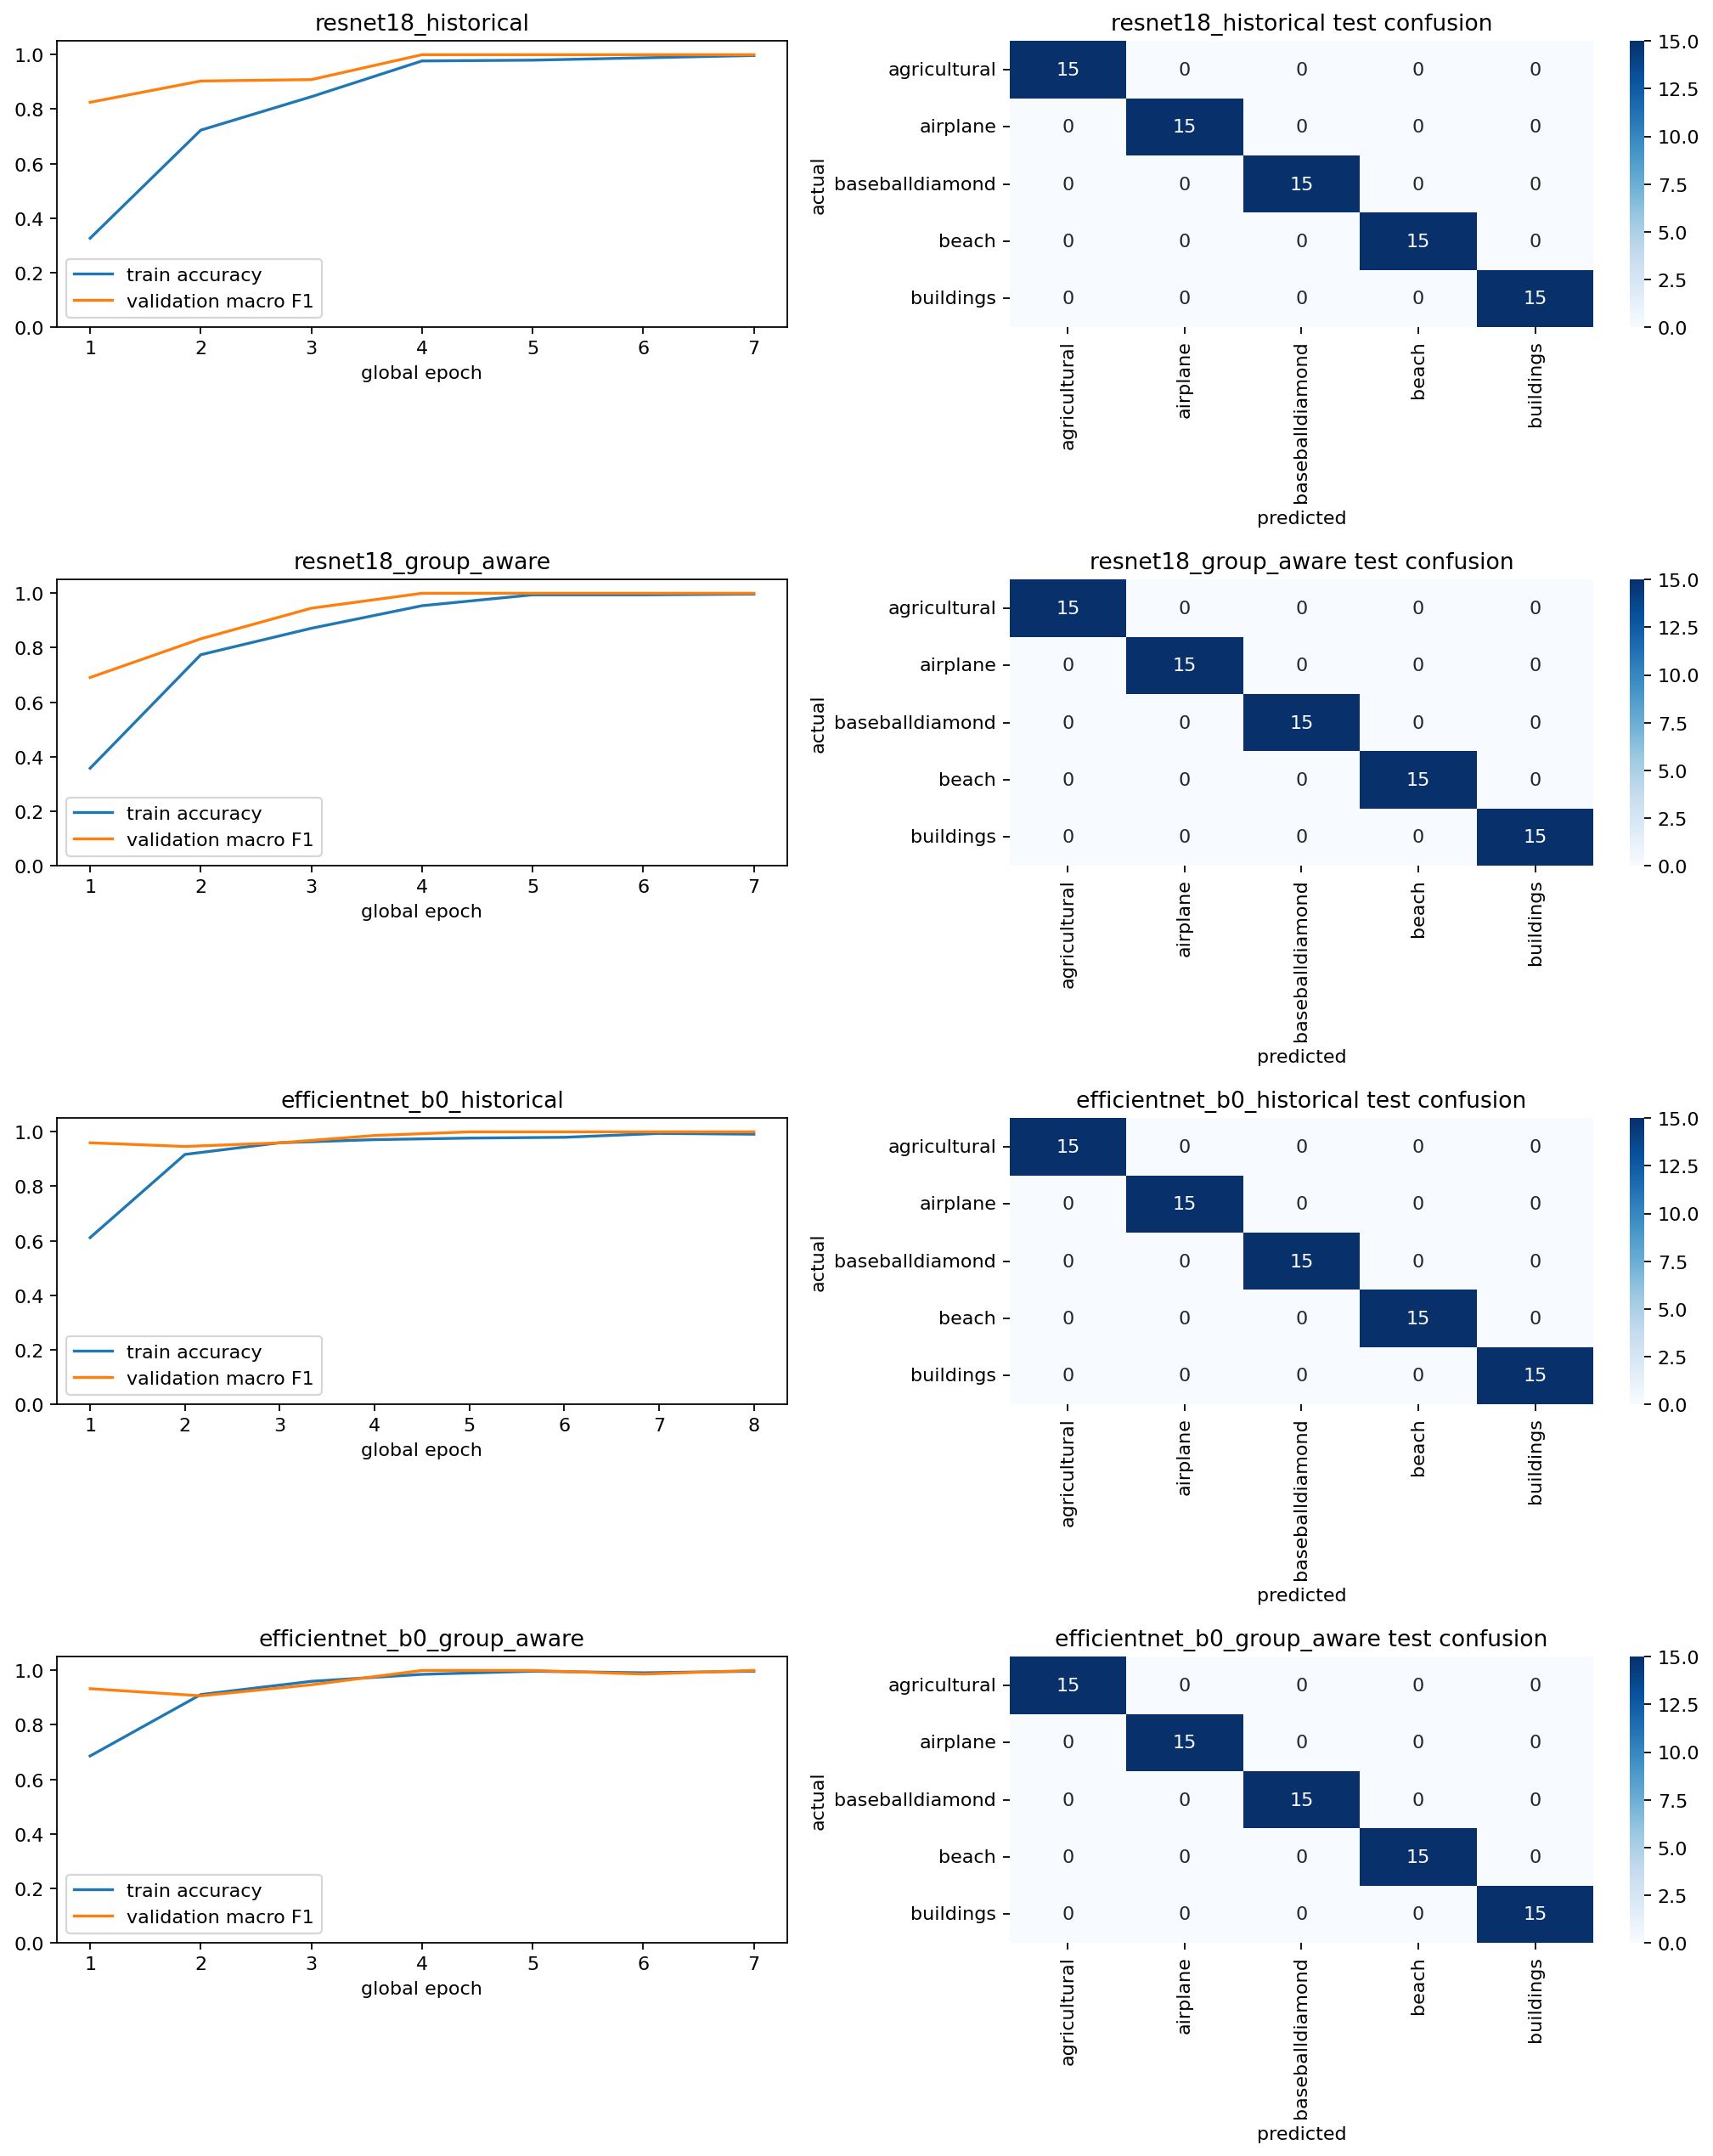

In [ ]:
%pip -q install "scikit-learn>=1.4" "seaborn>=0.13" "Pillow>=10"


In [ ]:
import csv
import hashlib
import json
import platform
import random
import shutil
import time
import urllib.request
import zipfile
from collections import Counter, defaultdict
from collections.abc import Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torchvision
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    ResNet18_Weights,
    efficientnet_b0,
    resnet18,
)

SEED = 42
SELECTED_CLASSES = (
    "agricultural", "airplane", "baseballdiamond", "beach", "buildings"
)
EXPECTED_COUNTS = {"train": 350, "validation": 75, "test": 75}
HISTORICAL_MANIFEST_SHA256 = (
    "73d19e048e742fdf616cbbc1f037efa009ea329ec600acef329f2a5bc7df87ea"
)
GROUP_MANIFEST_SHA256 = (
    "26bc3503f6a16e841286771b727e1f1f14a58c623deafe26c45e52d68b88081d"
)
ARCHIVE_URL = (
    "https://hf.co/datasets/torchgeo/ucmerced/resolve/"
    "d0af6e2eeea2322af86078068bd83337148a2149/UCMerced_LandUse.zip"
)
ARCHIVE_SHA256 = (
    "06c539ef28703a58fb07bd2837991ac7c48b813b00bb12ac197efd813a18daeb"
)
ARCHIVE_SIZE_BYTES = 332_468_434
SUPPLIED_BASELINE = {"accuracy": 0.7467, "macro_f1": 0.733}
RESULTS_EVIDENCE_COMMIT = "414233c8471ea961bfd9406a33f54b427e75ab49"

WORK_DIR = Path.cwd() / "terraclass_colab"
DATA_DIR = WORK_DIR / "data"
OUTPUT_DIR = WORK_DIR / "outputs"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
for directory in (DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. In Colab, choose Runtime > Change runtime type > GPU.")
print({"python": platform.python_version(), "torch": torch.__version__})


## 1. Verified dataset acquisition


In [ ]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def safe_extract(archive: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(archive) as bundle:
        for member in bundle.infolist():
            target = (destination / member.filename).resolve()
            if target != destination and destination not in target.parents:
                raise ValueError(f"Unsafe archive member: {member.filename}")
        bundle.extractall(destination)


archive_path = DATA_DIR / "UCMerced_LandUse.zip"
if not archive_path.exists():
    print("Downloading checksum-pinned UC Merced archive...")
    urllib.request.urlretrieve(ARCHIVE_URL, archive_path)
assert archive_path.stat().st_size == ARCHIVE_SIZE_BYTES, "Archive size mismatch"
assert sha256(archive_path) == ARCHIVE_SHA256, "Archive SHA-256 mismatch"

dataset_root = DATA_DIR / "UCMerced_LandUse" / "Images"
if not dataset_root.exists():
    safe_extract(archive_path, DATA_DIR)
assert dataset_root.is_dir()
print(f"Verified dataset: {dataset_root}")


## 2. Deterministic historical and group-aware manifests


In [ ]:
@dataclass(frozen=True)
class Sample:
    path: Path
    class_name: str
    label: int


def discover_samples(root: Path) -> list[Sample]:
    samples = []
    for label, class_name in enumerate(SELECTED_CLASSES):
        paths = sorted((root / class_name).glob("*.tif"))
        if len(paths) != 100:
            raise ValueError(f"{class_name}: expected 100 images, found {len(paths)}")
        samples.extend(Sample(path, class_name, label) for path in paths)
    return samples


def validate_splits(splits: dict[str, Sequence[Sample]]) -> None:
    if {name: len(items) for name, items in splits.items()} != EXPECTED_COUNTS:
        raise ValueError("Split counts differ from 350/75/75")
    all_paths = [sample.path.resolve() for items in splits.values() for sample in items]
    if len(all_paths) != len(set(all_paths)):
        raise ValueError("An image crosses split boundaries")
    for split_name, items in splits.items():
        expected_per_class = EXPECTED_COUNTS[split_name] // len(SELECTED_CLASSES)
        counts = Counter(sample.class_name for sample in items)
        if set(counts.values()) != {expected_per_class}:
            raise ValueError(f"Unbalanced {split_name}: {counts}")


def historical_split(samples: Sequence[Sample]) -> dict[str, list[Sample]]:
    labels = [sample.label for sample in samples]
    indices = list(range(len(samples)))
    train_indices, temporary_indices = train_test_split(
        indices, train_size=350, stratify=labels, random_state=SEED
    )
    temporary_labels = [labels[index] for index in temporary_indices]
    validation_indices, test_indices = train_test_split(
        temporary_indices,
        train_size=75,
        stratify=temporary_labels,
        random_state=SEED,
    )
    result = {
        "train": [samples[index] for index in train_indices],
        "validation": [samples[index] for index in validation_indices],
        "test": [samples[index] for index in test_indices],
    }
    validate_splits(result)
    return result


REVIEWED_GROUPS = {
    "agricultural/agricultural91.tif": "agricultural_related_91_94",
    "agricultural/agricultural94.tif": "agricultural_related_91_94",
    "airplane/airplane01.tif": "airplane_same_scene_01_02",
    "airplane/airplane02.tif": "airplane_same_scene_01_02",
    "beach/beach75.tif": "beach_related_75_79",
    "beach/beach77.tif": "beach_related_75_79",
    "beach/beach78.tif": "beach_related_75_79",
    "beach/beach79.tif": "beach_related_75_79",
    "beach/beach86.tif": "beach_related_86_91",
    "beach/beach87.tif": "beach_related_86_91",
    "beach/beach88.tif": "beach_related_86_91",
    "beach/beach89.tif": "beach_related_86_91",
    "beach/beach90.tif": "beach_related_86_91",
    "beach/beach91.tif": "beach_related_86_91",
}


def stable_seed(text: str) -> int:
    digest = hashlib.sha256(f"{SEED}:{text}".encode()).digest()
    return int.from_bytes(digest[:8], "big")


def group_aware_split(
    samples: Sequence[Sample], root: Path
) -> tuple[dict[str, list[Sample]], dict[str, str]]:
    relative_to_sample = {
        sample.path.resolve().relative_to(root.resolve()).as_posix(): sample
        for sample in samples
    }
    path_to_group = {
        relative: REVIEWED_GROUPS.get(
            relative, f"singleton::{sample.class_name}::{sample.path.stem}"
        )
        for relative, sample in relative_to_sample.items()
    }
    grouped: dict[str, dict[str, list[Sample]]] = defaultdict(
        lambda: defaultdict(list)
    )
    for relative, sample in relative_to_sample.items():
        grouped[sample.class_name][path_to_group[relative]].append(sample)

    split_order = ("train", "validation", "test")
    targets = {"train": 70, "validation": 15, "test": 15}
    result: dict[str, list[Sample]] = {name: [] for name in split_order}
    for class_name in SELECTED_CLASSES:
        class_groups = grouped[class_name]
        multi = sorted(
            ((key, value) for key, value in class_groups.items() if len(value) > 1),
            key=lambda item: (-len(item[1]), item[0]),
        )
        single = sorted(
            ((key, value) for key, value in class_groups.items() if len(value) == 1),
            key=lambda item: item[0],
        )
        random.Random(stable_seed(class_name)).shuffle(single)
        remaining = dict(targets)
        for _group_id, members in multi + single:
            eligible = [
                name for name in split_order if remaining[name] >= len(members)
            ]
            chosen = max(
                eligible,
                key=lambda name: (
                    remaining[name] / targets[name], -split_order.index(name)
                ),
            )
            result[chosen].extend(members)
            remaining[chosen] -= len(members)
        if any(remaining.values()):
            raise ValueError(f"Class capacity mismatch: {class_name} {remaining}")
    validate_splits(result)
    group_splits: dict[str, set[str]] = defaultdict(set)
    for split_name, items in result.items():
        for sample in items:
            relative = sample.path.relative_to(root).as_posix()
            group_splits[path_to_group[relative]].add(split_name)
    if any(len(names) > 1 for names in group_splits.values()):
        raise ValueError("A reviewed group crosses split boundaries")
    return result, path_to_group


In [ ]:
def write_manifest(
    destination: Path,
    splits: dict[str, Sequence[Sample]],
    root: Path,
    path_to_group: dict[str, str] | None = None,
) -> None:
    fields = ["split", "relative_path", "class_name", "label", "sha256"]
    if path_to_group is not None:
        fields.append("group_id")
    with destination.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        for split_name in ("train", "validation", "test"):
            for sample in sorted(splits[split_name], key=lambda item: str(item.path)):
                relative = sample.path.resolve().relative_to(root.resolve()).as_posix()
                row = {
                    "split": split_name,
                    "relative_path": relative,
                    "class_name": sample.class_name,
                    "label": sample.label,
                    "sha256": sha256(sample.path),
                }
                if path_to_group is not None:
                    row["group_id"] = path_to_group[relative]
                writer.writerow(row)


samples = discover_samples(dataset_root)
historical_splits = historical_split(samples)
group_splits, path_to_group = group_aware_split(samples, dataset_root)
historical_manifest = OUTPUT_DIR / "historical_manifest.csv"
group_manifest = OUTPUT_DIR / "group_aware_manifest.csv"
write_manifest(historical_manifest, historical_splits, dataset_root)
write_manifest(group_manifest, group_splits, dataset_root, path_to_group)
assert sha256(historical_manifest) == HISTORICAL_MANIFEST_SHA256
assert sha256(group_manifest) == GROUP_MANIFEST_SHA256

historical_group_locations: dict[str, set[str]] = defaultdict(set)
for split_name, items in historical_splits.items():
    for sample in items:
        relative = sample.path.relative_to(dataset_root).as_posix()
        if relative in REVIEWED_GROUPS:
            historical_group_locations[REVIEWED_GROUPS[relative]].add(split_name)
historical_crossings = {
    group_id: sorted(names)
    for group_id, names in historical_group_locations.items()
    if len(names) > 1
}
print("Historical reviewed-group crossings:", historical_crossings)
print("Group-aware reviewed-group crossings: {}")
print("Verified manifest hashes:", sha256(historical_manifest), sha256(group_manifest))


## 3. Input pipeline and transfer-learning models


In [ ]:
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
BATCH_SIZE = 16

train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)
eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class ImageDataset(Dataset):
    def __init__(self, items: Sequence[Sample], transform):
        self.items = list(items)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int):
        sample = self.items[index]
        with Image.open(sample.path) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, sample.label


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def make_loader(items: Sequence[Sample], transform, shuffle: bool) -> DataLoader:
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        ImageDataset(items, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=DEVICE.type == "cuda",
        generator=generator,
        persistent_workers=True,
    )


def build_model(architecture: str) -> nn.Module:
    if architecture == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(model.fc.in_features, 5))
        return model
    if architecture == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(features, 5))
        return model
    raise ValueError(f"Unsupported architecture: {architecture}")


def set_backbone_trainable(model: nn.Module, architecture: str, value: bool) -> None:
    head = model.fc if architecture == "resnet18" else model.classifier
    for parameter in model.parameters():
        parameter.requires_grad = value
    for parameter in head.parameters():
        parameter.requires_grad = True


## 4. Two-stage training and test-once evaluation


In [ ]:
def train_epoch(model, loader, criterion, optimizer, scaler) -> dict[str, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    amp_enabled = DEVICE.type == "cuda"
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp_enabled):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return {"loss": total_loss / total, "accuracy": correct / total}


def evaluate(model, loader, criterion) -> dict[str, Any]:
    model.eval()
    true_labels, predicted_labels = [], []
    total_loss = 0.0
    total = 0
    top3_correct = 0
    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            total += labels.size(0)
            predictions = outputs.argmax(1)
            top3 = outputs.topk(3, dim=1).indices
            top3_correct += top3.eq(labels.view(-1, 1)).any(dim=1).sum().item()
            true_labels.extend(labels.cpu().tolist())
            predicted_labels.extend(predictions.cpu().tolist())
    labels = list(range(len(SELECTED_CLASSES)))
    return {
        "loss": total_loss / total,
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(
            true_labels, predicted_labels, average="macro", zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            true_labels, predicted_labels
        ),
        "top3_accuracy": top3_correct / total,
        "confusion_matrix": confusion_matrix(
            true_labels, predicted_labels, labels=labels
        ).tolist(),
        "classification_report": classification_report(
            true_labels,
            predicted_labels,
            labels=labels,
            target_names=SELECTED_CLASSES,
            output_dict=True,
            zero_division=0,
        ),
    }


def run_experiment(
    architecture: str, split_kind: str, splits: dict[str, list[Sample]]
) -> dict[str, Any]:
    set_seed()
    train_loader = make_loader(splits["train"], train_transform, True)
    validation_loader = make_loader(splits["validation"], eval_transform, False)
    test_loader = make_loader(splits["test"], eval_transform, False)
    model = build_model(architecture).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    experiment_name = f"{architecture}_{split_kind}"
    checkpoint_path = CHECKPOINT_DIR / f"{experiment_name}.pth"
    manifest_hash = (
        HISTORICAL_MANIFEST_SHA256
        if split_kind == "historical"
        else GROUP_MANIFEST_SHA256
    )
    history = []
    best_score = -1.0
    selected = None
    global_epoch = 0
    started = time.perf_counter()
    stages = (("head", 3, 1e-3, False), ("fine_tune", 7, 1e-4, True))
    for stage, max_epochs, learning_rate, train_backbone in stages:
        set_backbone_trainable(model, architecture, train_backbone)
        optimizer = optim.AdamW(
            (p for p in model.parameters() if p.requires_grad),
            lr=learning_rate,
            weight_decay=1e-4,
        )
        without_improvement = 0
        for stage_epoch in range(1, max_epochs + 1):
            global_epoch += 1
            train_metrics = train_epoch(
                model, train_loader, criterion, optimizer, scaler
            )
            validation_metrics = evaluate(model, validation_loader, criterion)
            history.append(
                {
                    "global_epoch": global_epoch,
                    "stage": stage,
                    "stage_epoch": stage_epoch,
                    "train": train_metrics,
                    "validation": validation_metrics,
                }
            )
            score = validation_metrics["macro_f1"]
            print(
                f"{experiment_name} epoch={global_epoch} stage={stage} "
                f"train_acc={train_metrics['accuracy']:.3f} "
                f"val_f1={score:.3f}"
            )
            if score > best_score:
                best_score = score
                without_improvement = 0
                selected = {
                    "global_epoch": global_epoch,
                    "stage": stage,
                    "stage_epoch": stage_epoch,
                    "validation_macro_f1": score,
                }
                torch.save(model.state_dict(), checkpoint_path)
            else:
                without_improvement += 1
            if without_improvement >= 3:
                break

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    )
    test_metrics = evaluate(model, test_loader, criterion)
    elapsed_seconds = time.perf_counter() - started
    result = {
        "schema_version": 1,
        "experiment_name": experiment_name,
        "architecture": architecture,
        "split_kind": split_kind,
        "seed": SEED,
        "device": str(DEVICE),
        "manifest_sha256": manifest_hash,
        "total_parameters": sum(p.numel() for p in model.parameters()),
        "selected": selected,
        "elapsed_seconds": elapsed_seconds,
        "history": history,
        "test": test_metrics,
    }
    (OUTPUT_DIR / f"{experiment_name}.json").write_text(
        json.dumps(result, indent=2) + "\n", encoding="utf-8"
    )
    return result


## 5. GPU experiment matrix

Run this cell once. On Colab Pro, select a GPU runtime first. All four configurations
are attempted independently; a failed experiment is recorded and does not erase the
completed results.


In [ ]:
RUN_EFFICIENTNET = True
experiment_specs = [
    ("resnet18", "historical", historical_splits),
    ("resnet18", "group_aware", group_splits),
]
if RUN_EFFICIENTNET:
    experiment_specs.extend(
        [
            ("efficientnet_b0", "historical", historical_splits),
            ("efficientnet_b0", "group_aware", group_splits),
        ]
    )

results: list[dict[str, Any]] = []
failures: list[dict[str, str]] = []
for architecture, split_kind, splits in experiment_specs:
    try:
        results.append(run_experiment(architecture, split_kind, splits))
    except Exception as error:
        failure = {
            "architecture": architecture,
            "split_kind": split_kind,
            "error_type": type(error).__name__,
            "message": str(error),
        }
        failures.append(failure)
        print("FAILED:", failure)

assert results, "No experiment completed"
print(f"Completed: {len(results)}; failed: {len(failures)}")


## 6. Comparison, visual evaluation, and export


In [ ]:
rows = [
    {
        "model": "supplied_custom_cnn",
        "split": "historical",
        "accuracy": SUPPLIED_BASELINE["accuracy"],
        "macro_f1": SUPPLIED_BASELINE["macro_f1"],
        "balanced_accuracy": np.nan,
        "top3_accuracy": np.nan,
        "selected_epoch": 10,
        "elapsed_seconds": np.nan,
    }
]
for result in results:
    rows.append(
        {
            "model": result["architecture"],
            "split": result["split_kind"],
            "accuracy": result["test"]["accuracy"],
            "macro_f1": result["test"]["macro_f1"],
            "balanced_accuracy": result["test"]["balanced_accuracy"],
            "top3_accuracy": result["test"]["top3_accuracy"],
            "selected_epoch": result["selected"]["global_epoch"],
            "elapsed_seconds": result["elapsed_seconds"],
        }
    )
comparison = pd.DataFrame(rows)
display(comparison.style.format({
    "accuracy": "{:.3f}", "macro_f1": "{:.3f}",
    "balanced_accuracy": "{:.3f}", "top3_accuracy": "{:.3f}",
    "elapsed_seconds": "{:.1f}",
}))
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

figure, axes = plt.subplots(len(results), 2, figsize=(13, 4 * len(results)))
if len(results) == 1:
    axes = np.array([axes])
for row_index, result in enumerate(results):
    epochs = [entry["global_epoch"] for entry in result["history"]]
    train_accuracy = [entry["train"]["accuracy"] for entry in result["history"]]
    validation_f1 = [
        entry["validation"]["macro_f1"] for entry in result["history"]
    ]
    axes[row_index, 0].plot(epochs, train_accuracy, label="train accuracy")
    axes[row_index, 0].plot(epochs, validation_f1, label="validation macro F1")
    axes[row_index, 0].set_title(result["experiment_name"])
    axes[row_index, 0].set_xlabel("global epoch")
    axes[row_index, 0].set_ylim(0, 1.05)
    axes[row_index, 0].legend()
    sns.heatmap(
        result["test"]["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SELECTED_CLASSES,
        yticklabels=SELECTED_CLASSES,
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"{result['experiment_name']} test confusion")
    axes[row_index, 1].set_xlabel("predicted")
    axes[row_index, 1].set_ylabel("actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_and_confusion.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
run_report = {
    "schema_version": 1,
    "results_evidence_commit": RESULTS_EVIDENCE_COMMIT,
    "hardware": {
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
    },
    "environment": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "dataset": {
        "archive_sha256": ARCHIVE_SHA256,
        "selected_classes": list(SELECTED_CLASSES),
        "selected_images": 500,
    },
    "historical_manifest_sha256": HISTORICAL_MANIFEST_SHA256,
    "group_manifest_sha256": GROUP_MANIFEST_SHA256,
    "results": results,
    "failures": failures,
}
(OUTPUT_DIR / "colab_run_report.json").write_text(
    json.dumps(run_report, indent=2) + "\n", encoding="utf-8"
)
export_base = WORK_DIR / "terraclass_colab_results"
export_zip = Path(shutil.make_archive(str(export_base), "zip", OUTPUT_DIR))
print(f"Results bundle: {export_zip} ({export_zip.stat().st_size:,} bytes)")

try:
    from google.colab import files
    files.download(str(export_zip))
except ImportError:
    print("Not running in Colab; download the results bundle manually.")


## 7. Result interpretation and limitations

Use only the generated comparison table when writing the final numerical conclusion.
The historical result answers whether transfer learning improves the supplied
assignment;
the group-aware result tests sensitivity to reviewed related scenes. EfficientNet-B0 is
claimable only if its run completed and appears in the exported report.

**Limitations:** This experiment uses a balanced 500-image subset with five visually
distinct classes, not all 21 UC Merced classes. ImageNet pretraining transfers external
visual knowledge. The test set contains only 75 images, so a perfect score must retain
this scope and must not be advertised as a universally perfect satellite classifier.
The manually reviewed grouping policy covers conservative perceptual-hash candidates and
may not capture every semantically related scene.

**Collaboration hand-off:** Return `terraclass_colab_results.zip` to Codex. The final
notebook will then be updated with verified GPU outputs and the exact submission commit.
